In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0310_dps.fits')

In [4]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()

In [14]:
example_id = 39627781725753388
example_df = dps_df[dps_df['TARGETID'] == example_id].iloc[0]
example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])
lam, flux, ivar = DP_SPECTRA.data_stack[example_idx, 0, :], DP_SPECTRA.data_stack[example_idx, 1, :], DP_SPECTRA.data_stack[example_idx, 2, :]
sigma = 1/np.sqrt(np.abs(ivar))


In [15]:
test_1comp = model_1comp[example_idx]
test_2comp_l = left_2comp[example_idx]
test_2comp_r = right_2comp[example_idx]
test_2comp = test_2comp_l + test_2comp_r

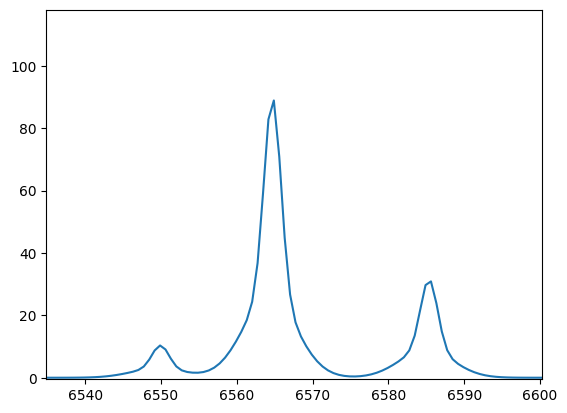

In [16]:
plt.plot(lam, test_2comp, label='Observed Spectrum')
plt.xlim((NII_rest[0]-15, NII_rest[1]+15))
plt.ylim(bottom=-0.5)
plt.show()